# Notebook 3 — Feature Engineering, EDA & Split Train/Validation


## Structure du notebook

```
1. Imports & Configuration
2. Chargement des données brutes (Notebook 2)
3. Extraction features Train  (94 existantes + 7 complexité + Kraken2)
4. Extraction features Test   (mêmes familles)
5. Split Train / Validation sans data leakage
6. EDA — Analyse exploratoire des features
7. Sauvegarde 
```

## Catalogue des features

| Famille | N | Justification |
|---------|---|---------------|
| Fractions brutes (pct_A/T/C/G/GC) | 5 | Composition directe |
| Qualité brute (avg_quality, num_reads, avg_read_length) | 3 | Profondeur séquençage |
| Ratios biologiques (gc_skew, at_skew, R/Y, entropie) | 4 | Lobry 1996 ; Forsdyke 2000 |
| K-mers k=3 (kmer_AAA…TTT) | 64 | Woloszynek 2019 ; MicroPheno 2018 |
| Dinucléotides relatifs rho(XY) | 16 | Karlin & Burge 1995 |
| Qualité différenciée (Q20/Q30) | 2 | Standard Illumina |
| **Complexité séquentielle**    | 7 | Proxy diversité taxonomique |
| **Taxonomie Kraken2**       | ≤500 | Knights 2011 ; Wood 2019 |


## 1. Imports & Configuration

In [ ]:
# téléchargement de l'image docker de kraken2
# !docker pull staphb/kraken2

Using default tag: latest
latest: Pulling from staphb/kraken2
Digest: sha256:36941eebe0fb0277330bec3db06a1d348c6ec06773d0941082efae750cde0e1f
Status: Image is up to date for staphb/kraken2:latest
docker.io/staphb/kraken2:latest


In [2]:
# pour télécharger la base de données silva pour kraken2, il faut d'abord créer un dossier local pour stocker la base de données, puis utiliser docker pour exécuter la commande de téléchargement de la base de données.
# !mkdir -p data/kraken2_silva_db

# !docker run --rm \
#   -v $(pwd)/data/kraken2_silva_db:/db \
#   staphb/kraken2 \
#   kraken2-build --special silva --db /db

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor, as_completed
import os, sys, psutil, warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

sys.path.append('../src')
from feature_engineering import (
    build_features,
    split_by_subject,
    # extract_fastq_features,
    compute_sequence_complexity_features,
    check_kraken2,
    build_taxonomic_features,
)

print('✅ Imports OK')

✅ Imports OK


In [4]:
PROCESSED_PATH = Path('../data/processed')
FIGURES_PATH   = Path('../results/figures')
TRAIN_MGB_PATH = Path('../data/raw/TrainFiles')
TEST_MGB_PATH  = Path('../data/raw/TestFiles')
KRAKEN2_DB     = '../data/kraken2_silva_db'  # adapter si nécessaire

META_COLS  = ['filename', 'SubjectID', 'SampleID', 'SampleType']
META_COLS_TEST = ['filename']

available_gb = psutil.virtual_memory().available / 1e9
N_WORKERS    = max(1, os.cpu_count() - 1)

_SRC_ABS = str(Path('../src').resolve())

print(f'Workers : {N_WORKERS}  |  RAM disponible : {available_gb:.1f} GB')
print(f'Chemins configurés :')
print(f'  Train FASTQ : {TRAIN_MGB_PATH.absolute()}')
print(f'  Test FASTQ  : {TEST_MGB_PATH.absolute()}')
print(f'  Processed   : {PROCESSED_PATH.absolute()}')


Workers : 11  |  RAM disponible : 25.0 GB
Chemins configurés :
  Train FASTQ : /home/barry-4mad/Desktop/mpeg/fl-microbiome-mpegG/notebook/../data/raw/TrainFiles
  Test FASTQ  : /home/barry-4mad/Desktop/mpeg/fl-microbiome-mpegG/notebook/../data/raw/TestFiles
  Processed   : /home/barry-4mad/Desktop/mpeg/fl-microbiome-mpegG/notebook/../data/processed


## 2. Chargement des données brutes (output Notebook 2)

In [5]:
df_train_fastq = pd.read_csv(PROCESSED_PATH / 'train_fastq_features.csv')
df_test_fastq  = pd.read_csv(PROCESSED_PATH / 'test_fastq_features.csv')

print(f'Train : {df_train_fastq.shape}')
print(f'Test  : {df_test_fastq.shape}')
print(f'\nSujets uniques : {df_train_fastq["SubjectID"].nunique()}')
print(f'Distribution SampleType :')
print(df_train_fastq['SampleType'].value_counts())


Train : (2901, 12)
Test  : (1068, 9)

Sujets uniques : 66
Distribution SampleType :
SampleType
Stool    811
Skin     787
Nasal    710
Mouth    593
Name: count, dtype: int64


In [6]:
# Worker parallèle — défini une seule fois, réutilisé pour train et test
def _worker_fastq(args):
    idx, filename, fastq_dir, src_abs = args

    import sys; sys.path.insert(0, src_abs)
    from feature_engineering import extract_fastq_features
    from pathlib import Path

    fastq_path = Path(fastq_dir) / filename.replace('.mgb', '.fastq')
    return idx, extract_fastq_features(fastq_path)


def run_fastq_pipeline(df, fastq_dir, n_workers, desc):
    """Extrait k-mers, dinucléotides et Q20/Q30 en parallèle."""

    args_list = [(idx, row['filename'], str(fastq_dir), _SRC_ABS)
                 for idx, row in df.iterrows()]
    rows_kmer, rows_di, rows_qual, valid_indices = [], [], [], []
    
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(_worker_fastq, a): a[0] for a in args_list}
        for future in tqdm(as_completed(futures), total=len(futures), desc=desc):
            idx, feats = future.result()
            if feats is None:
                continue
            rows_kmer.append({k: feats[k] for k in feats if k.startswith('kmer_')})
            rows_di.append(  {k: feats[k] for k in feats if k.startswith('di_')})
            rows_qual.append({k: feats[k] for k in feats if k.startswith('pct_bases_')})
            valid_indices.append(idx)
    valid_indices.sort()
    return rows_kmer, rows_di, rows_qual, valid_indices


print('✅ Pipeline worker défini')


✅ Pipeline worker défini


## 3. Extraction des features — Train

Toutes les familles de features sont extraites ici, dans l'ordre :
1. Features de base (depuis pct_*)
2. K-mers, dinucléotides, Q20/Q30 (depuis FASTQ, parallèle)
3. Complexité séquentielle (LZ, ambiguous, distribution longueurs)
4. Taxonomie Kraken2 (si disponible)

In [7]:
# ── 3.1 Features de base (depuis pct_A/T/C/G) ───────────────────────────
base_train = build_features(df_train_fastq)
print(f'3.1 Base features : {base_train.shape[1]}')


✅ 12 features construites :
   Brutes    : pct_A, pct_T, pct_C, pct_G, pct_GC, avg_quality, num_reads, avg_read_length
   Dérivées  : gc_skew, at_skew, purine_pyrimidine_ratio, nucleotide_entropy
3.1 Base features : 12


In [8]:
# ── 3.2 K-mers, dinucléotides, Q20/Q30 (depuis FASTQ) ──────────────────
print(f'⏰ Début : {datetime.now().strftime("%H:%M:%S")}')

rows_kmer_train, rows_di_train, rows_qual_train, valid_idx_train = run_fastq_pipeline(df_train_fastq, TRAIN_MGB_PATH, N_WORKERS, '📂 FASTQ train')

print(f'⏰ Fin   : {datetime.now().strftime("%H:%M:%S")}')
print(f'✅ {len(valid_idx_train)}/{len(df_train_fastq)} échantillons traités')

# Aligner df_train sur les fichiers valides
df_train_valid = df_train_fastq.loc[valid_idx_train].reset_index(drop=True)
base_train     = build_features(df_train_valid)  # recalcul sur df aligné

kmer_train = pd.DataFrame(rows_kmer_train)
di_train   = pd.DataFrame(rows_di_train)
qual_train = pd.DataFrame(rows_qual_train)

print(f'  K-mers     : {kmer_train.shape[1]}')
print(f'  Di-nucl.   : {di_train.shape[1]}')
print(f'  Q20/Q30    : {qual_train.shape[1]}')


⏰ Début : 23:29:21


📂 FASTQ train: 100%|██████████| 2901/2901 [06:46<00:00,  7.13it/s]


⏰ Fin   : 23:36:08
✅ 2901/2901 échantillons traités
✅ 12 features construites :
   Brutes    : pct_A, pct_T, pct_C, pct_G, pct_GC, avg_quality, num_reads, avg_read_length
   Dérivées  : gc_skew, at_skew, purine_pyrimidine_ratio, nucleotide_entropy
  K-mers     : 64
  Di-nucl.   : 16
  Q20/Q30    : 2


In [9]:
# ── 3.3 Complexité séquentielle ──────────────────────────────────────────
print('⚙️  Complexité séquentielle — Train...')
complexity_train = []
for _, row in tqdm(df_train_valid.iterrows(), total=len(df_train_valid), desc='Complexité train'):
    fp  = str(TRAIN_MGB_PATH / row['filename'].replace('.mgb', '.fastq'))
    res = compute_sequence_complexity_features(fp, sample_size=2000)
    complexity_train.append(res if res else {})

complexity_train_df = pd.DataFrame(complexity_train).fillna(0.0)
print(f'✅ {complexity_train_df.shape[1]} features de complexité — Train')


⚙️  Complexité séquentielle — Train...


Complexité train: 100%|██████████| 2901/2901 [12:06<00:00,  3.99it/s]   

✅ 7 features de complexité — Train


In [10]:
# ── 3.4 Taxonomie Kraken2 ────────────────────────────────────

KRAKEN2_AVAILABLE = check_kraken2() and Path(KRAKEN2_DB).exists()
print(f'Kraken2 disponible : {KRAKEN2_AVAILABLE}')

if KRAKEN2_AVAILABLE:
    fastq_paths_train = [
        str(TRAIN_MGB_PATH / row['filename'].replace('.mgb', '.fastq'))
        for _, row in df_train_valid.iterrows()
    ]
    
    print(f'\n⚙️  Kraken2 — Train ({len(fastq_paths_train)} fichiers)...')
    tax_train_df = build_taxonomic_features(fastq_paths_train, KRAKEN2_DB, min_prevalence=0.05, threads=N_WORKERS)
else:
    print('⚠️  Kraken2 non disponible — features taxonomiques ignorées')
    tax_train_df = pd.DataFrame(index=range(len(df_train_valid)))


Kraken2 disponible : True

⚙️  Kraken2 — Train (2901 fichiers)...
🔬 Kraken2 (Docker) — 2901 échantillons


Kraken2: 100%|██████████| 2901/2901 [6:10:25<00:00,  7.66s/it]       


✅ Taxonomie Kraken2 :
   Genres détectés  : 2680
   Genres conservés : 101  (prévalence ≥ 5%)
   Features totales : 103


In [11]:
# ── 3.5 Assemblage final Train ───────────────────────────────────────────
parts_train = [
    df_train_valid[META_COLS].reset_index(drop=True),
    base_train.reset_index(drop=True),
    kmer_train.reset_index(drop=True),
    di_train.reset_index(drop=True),
    qual_train.reset_index(drop=True),
    complexity_train_df.reset_index(drop=True),
]
if not tax_train_df.empty:
    parts_train.append(tax_train_df.reset_index(drop=True))

df_train_final = pd.concat(parts_train, axis=1)
feature_cols   = [c for c in df_train_final.columns if c not in META_COLS]

print(f'\n{"="*50}')
print(f'TRAIN — Features assemblées')
print(f'{"="*50}')
print(f'  Shape          : {df_train_final.shape}')
print(f'  Features totales : {len(feature_cols)}')
print(f'    Base + dérivées : {base_train.shape[1]}')
print(f'    K-mers (k=3)    : {kmer_train.shape[1]}')
print(f'    Dinucléotides   : {di_train.shape[1]}')
print(f'    Q20/Q30         : {qual_train.shape[1]}')
print(f'    Complexité      : {complexity_train_df.shape[1]}')
n_tax = tax_train_df.shape[1] if not tax_train_df.empty else 0
print(f'    Kraken2         : {n_tax}')
print(f'{"="*50}')



TRAIN — Features assemblées
  Shape          : (2901, 208)
  Features totales : 204
    Base + dérivées : 12
    K-mers (k=3)    : 64
    Dinucléotides   : 16
    Q20/Q30         : 2
    Complexité      : 7
    Kraken2         : 103


## 4. Extraction des features — Test

Mêmes familles que le train, dans le même ordre.  
Pas de `SampleType` ni de `SubjectID` — uniquement `filename`.

In [12]:
# ── 4.1 K-mers, dinucléotides, Q20/Q30 ──────────────────────────────────
print(f'⏰ Début : {datetime.now().strftime("%H:%M:%S")}')

rows_kmer_test, rows_di_test, rows_qual_test, valid_idx_test = run_fastq_pipeline(
    df_test_fastq, TEST_MGB_PATH, N_WORKERS, '📂 FASTQ test'
)

print(f'⏰ Fin   : {datetime.now().strftime("%H:%M:%S")}')
print(f'✅ {len(valid_idx_test)}/{len(df_test_fastq)} échantillons traités')

df_test_valid = df_test_fastq.loc[valid_idx_test].reset_index(drop=True)
base_test     = build_features(df_test_valid)
kmer_test     = pd.DataFrame(rows_kmer_test)
di_test       = pd.DataFrame(rows_di_test)
qual_test     = pd.DataFrame(rows_qual_test)


⏰ Début : 05:58:41


📂 FASTQ test: 100%|██████████| 1068/1068 [01:59<00:00,  8.97it/s]


⏰ Fin   : 06:00:41
✅ 1068/1068 échantillons traités
✅ 12 features construites :
   Brutes    : pct_A, pct_T, pct_C, pct_G, pct_GC, avg_quality, num_reads, avg_read_length
   Dérivées  : gc_skew, at_skew, purine_pyrimidine_ratio, nucleotide_entropy


In [13]:
# ── 4.2 Complexité séquentielle ──────────────────────────────────────────
print('⚙️  Complexité séquentielle — Test...')
complexity_test = []
for _, row in tqdm(df_test_valid.iterrows(), total=len(df_test_valid),
                   desc='Complexité test'):
    fp  = str(TEST_MGB_PATH / row['filename'].replace('.mgb', '.fastq'))
    res = compute_sequence_complexity_features(fp, sample_size=2000)
    complexity_test.append(res if res else {})

complexity_test_df = pd.DataFrame(complexity_test).fillna(0.0)
print(f'✅ {complexity_test_df.shape[1]} features de complexité — Test')


⚙️  Complexité séquentielle — Test...


Complexité test: 100%|██████████| 1068/1068 [05:04<00:00,  3.50it/s]

✅ 7 features de complexité — Test


In [14]:
# ── 4.3 Taxonomie Kraken2 ────────────────────────────────────
if KRAKEN2_AVAILABLE:
    fastq_paths_test = [
        str(TEST_MGB_PATH / row['filename'].replace('.mgb', '.fastq'))
        for _, row in df_test_valid.iterrows()
    ]
    print(f'⚙️  Kraken2 — Test ({len(fastq_paths_test)} fichiers)...')
    tax_test_df = build_taxonomic_features(
        fastq_paths_test, KRAKEN2_DB, min_prevalence=0.05, threads=N_WORKERS
    )
else:
    tax_test_df = pd.DataFrame(index=range(len(df_test_valid)))


⚙️  Kraken2 — Test (1068 fichiers)...
🔬 Kraken2 (Docker) — 1068 échantillons


Kraken2: 100%|██████████| 1068/1068 [15:46<00:00,  1.13it/s]


✅ Taxonomie Kraken2 :
   Genres détectés  : 2305
   Genres conservés : 92  (prévalence ≥ 5%)
   Features totales : 94


In [15]:
# ── 4.4 Assemblage final Test ────────────────────────────────────────────
parts_test = [
    df_test_valid[['filename']].reset_index(drop=True),
    base_test.reset_index(drop=True),
    kmer_test.reset_index(drop=True),
    di_test.reset_index(drop=True),
    qual_test.reset_index(drop=True),
    complexity_test_df.reset_index(drop=True),
]
if not tax_test_df.empty:
    parts_test.append(tax_test_df.reset_index(drop=True))

df_test_final = pd.concat(parts_test, axis=1)

# Aligner les colonnes test sur train (colonnes manquantes → 0)
test_feat_cols = [c for c in df_test_final.columns if c != 'filename']
missing_cols   = set(feature_cols) - set(test_feat_cols)
if missing_cols:
    print(f'⚠️  {len(missing_cols)} colonnes absentes dans test → remplissage à 0')
    for col in missing_cols:
        df_test_final[col] = 0.0
df_test_final = df_test_final[['filename'] + feature_cols]  # même ordre que train

print(f'✅ Test assemblé : {df_test_final.shape}')


⚠️  11 colonnes absentes dans test → remplissage à 0
✅ Test assemblé : (1068, 205)


## 5. Split Train / Validation sans data leakage

Split au niveau des **sujets** (SubjectID), pas des échantillons.  
Un même sujet ayant fourni des échantillons de plusieurs sites, un split  
aléatoire par échantillon placerait le même patient dans train ET validation  
→ data leakage → métriques artificiellement gonflées.

La stratification s'appuie sur le SampleType dominant de chaque sujet.

In [16]:
# Analyse préliminaire : sujets multi-sites
subject_types = df_train_final.groupby('SubjectID')['SampleType'].nunique()
mono_site  = (subject_types == 1).sum()
multi_site = (subject_types > 1).sum()
print(f'Sujets mono-site  : {mono_site} ({100*mono_site/len(subject_types):.1f}%)')
print(f'Sujets multi-site : {multi_site} ({100*multi_site/len(subject_types):.1f}%)')
print(f'→ {multi_site} sujets créeraient du leakage avec un split aléatoire')


Sujets mono-site  : 1 (1.5%)
Sujets multi-site : 65 (98.5%)
→ 65 sujets créeraient du leakage avec un split aléatoire


In [17]:
train_df, val_df = split_by_subject(
    df_train_final,
    subject_col='SubjectID',
    target_col='SampleType',
    val_size=0.2,
    random_state=42
)


SPLIT TRAIN / VALIDATION (par SubjectID)
  Sujets train :  54  |  Échantillons : 2463
  Sujets val   :  12  |  Échantillons :  438

  Distribution SampleType — TRAIN :
    Stool      :  713 (28.9%)
    Skin       :  650 (26.4%)
    Nasal      :  607 (24.6%)
    Mouth      :  493 (20.0%)
  Distribution SampleType — VAL :
    Skin       :  137 (31.3%)
    Nasal      :  103 (23.5%)
    Mouth      :  100 (22.8%)
    Stool      :   98 (22.4%)
✅ Vérification anti-leakage : OK


## 6. EDA — Analyse exploratoire des features

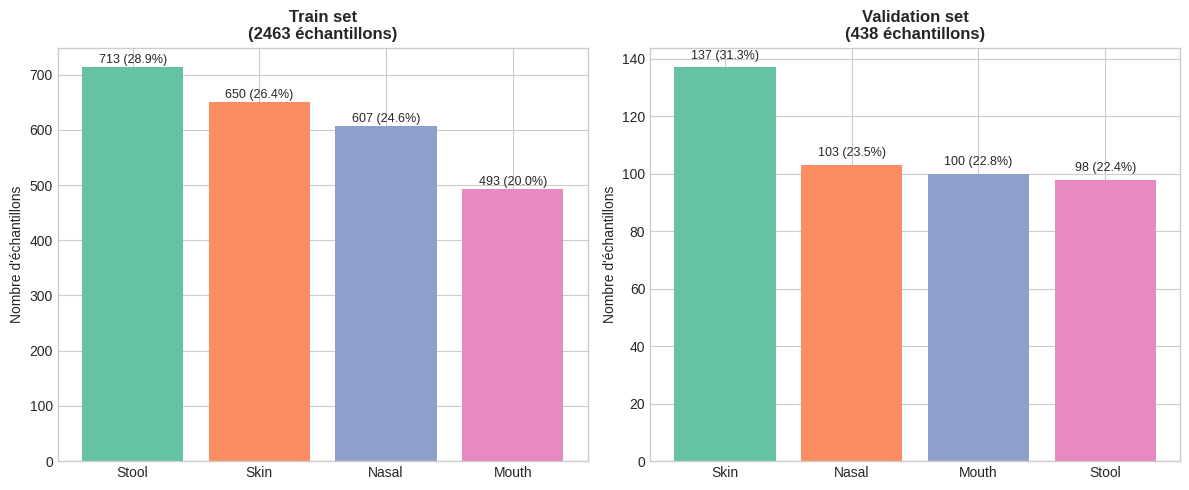

In [18]:
# Distribution des classes dans train vs val
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title in zip(axes, [train_df, val_df], ['Train set', 'Validation set']):
    counts = data['SampleType'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette('Set2', len(counts)))
    ax.set_title(f'{title}\n({len(data)} échantillons)', fontweight='bold')
    ax.set_ylabel("Nombre d'échantillons")
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                f'{count} ({100*count/len(data):.1f}%)',
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_train_val_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


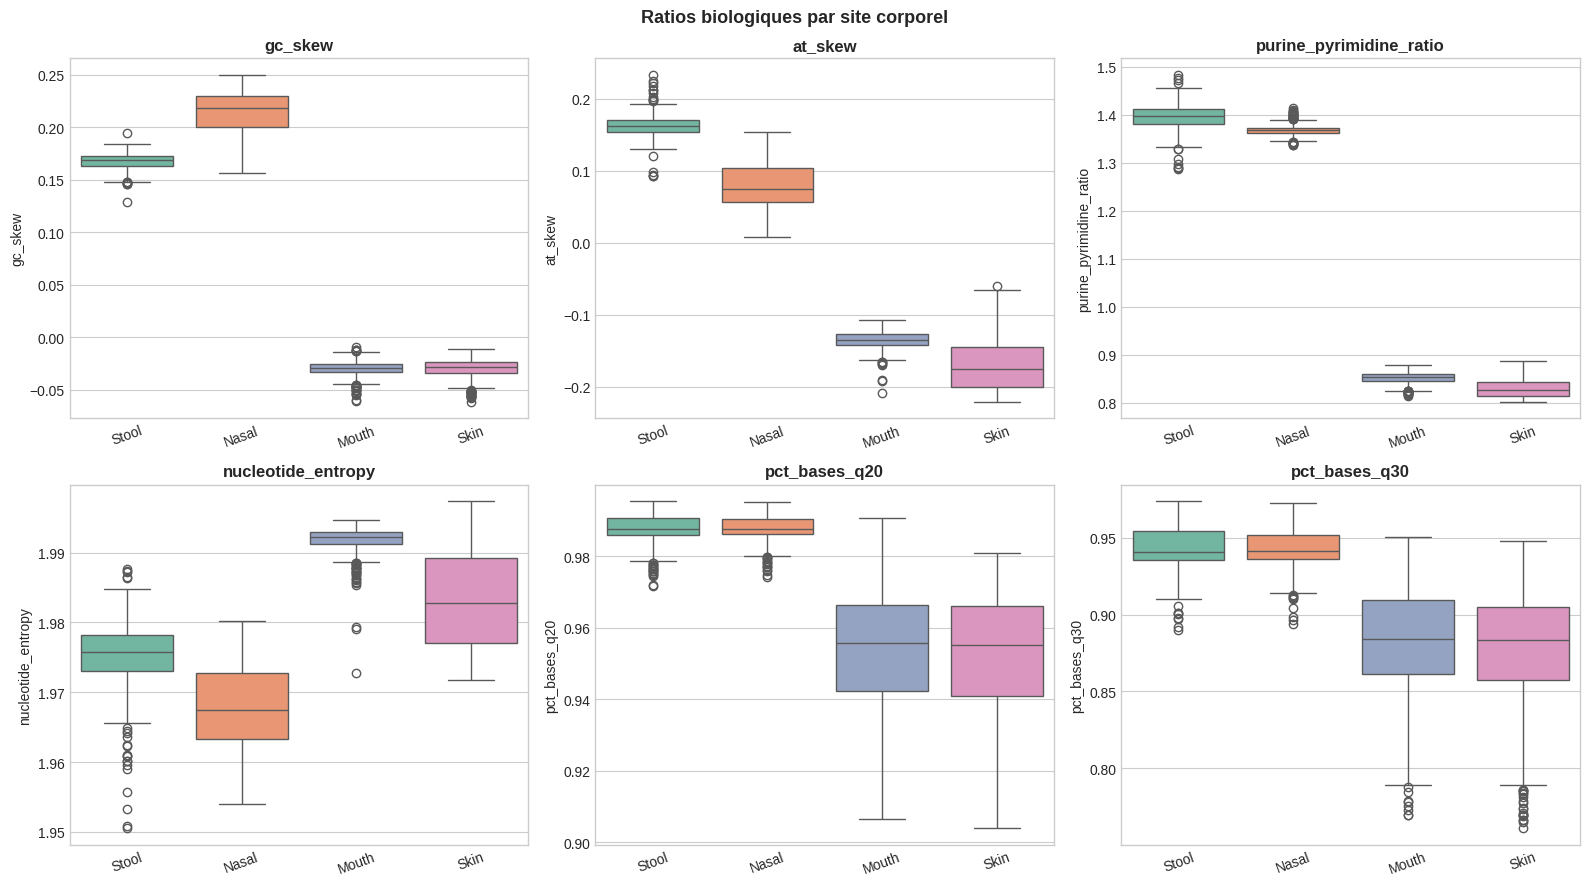

In [19]:
# Ratios biologiques par site corporel
derived_features = ['gc_skew', 'at_skew', 'purine_pyrimidine_ratio',
                    'nucleotide_entropy', 'pct_bases_q20', 'pct_bases_q30']
derived_available = [f for f in derived_features if f in df_train_final.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, feat in zip(axes, derived_available):
    sns.boxplot(data=df_train_final, x='SampleType', y=feat, ax=ax, palette='Set2')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
for ax in axes[len(derived_available):]:
    ax.set_visible(False)
plt.suptitle('Ratios biologiques par site corporel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_derived_features_by_sampletype.png', dpi=150, bbox_inches='tight')
plt.show()


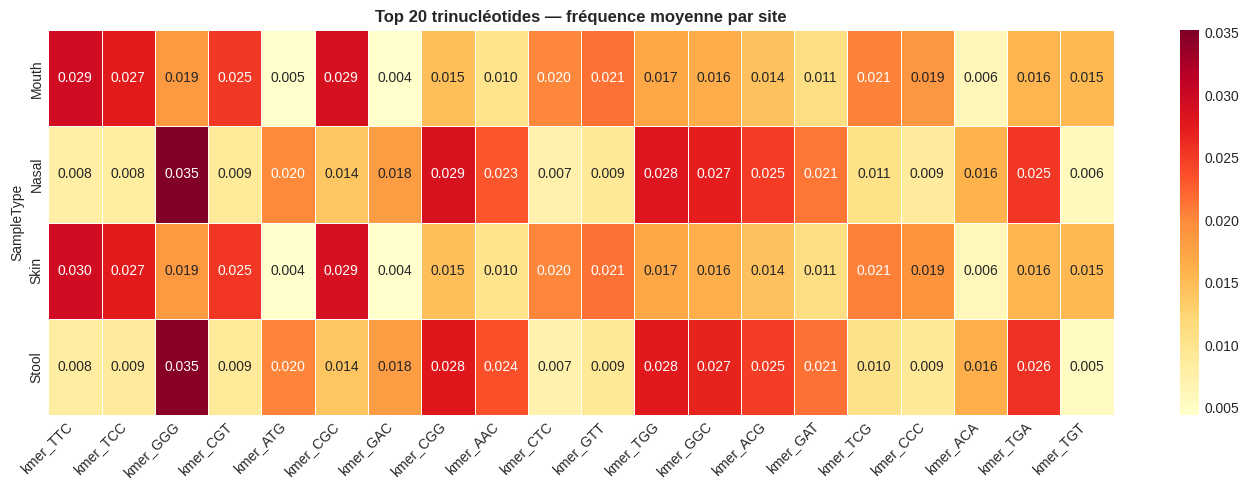

In [20]:
# Top 20 k-mers discriminants (variance inter-sites)
kmer_cols = [c for c in df_train_final.columns if c.startswith('kmer_')]
if kmer_cols:
    kmer_by_site   = df_train_final.groupby('SampleType')[kmer_cols].mean()
    inter_site_var = kmer_by_site.var(axis=0)
    top20_kmers    = inter_site_var.nlargest(20).index.tolist()

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(kmer_by_site[top20_kmers], annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title('Top 20 trinucléotides — fréquence moyenne par site', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '03_top20_kmers_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


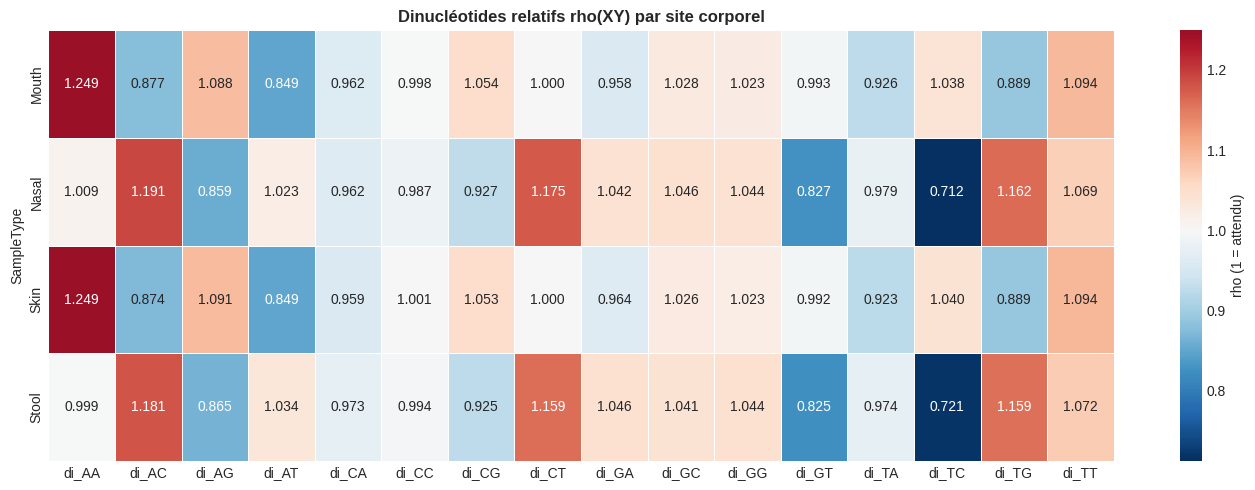

In [21]:
# Dinucléotides relatifs rho(XY) par site
di_cols = [c for c in df_train_final.columns if c.startswith('di_')]
if di_cols:
    di_by_site = df_train_final.groupby('SampleType')[di_cols].mean()
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(di_by_site, annot=True, fmt='.3f', cmap='RdBu_r', center=1.0,
                ax=ax, linewidths=0.5, cbar_kws={'label': 'rho (1 = attendu)'})
    ax.set_title('Dinucléotides relatifs rho(XY) par site corporel', fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '03_dinucleotides_relatifs_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


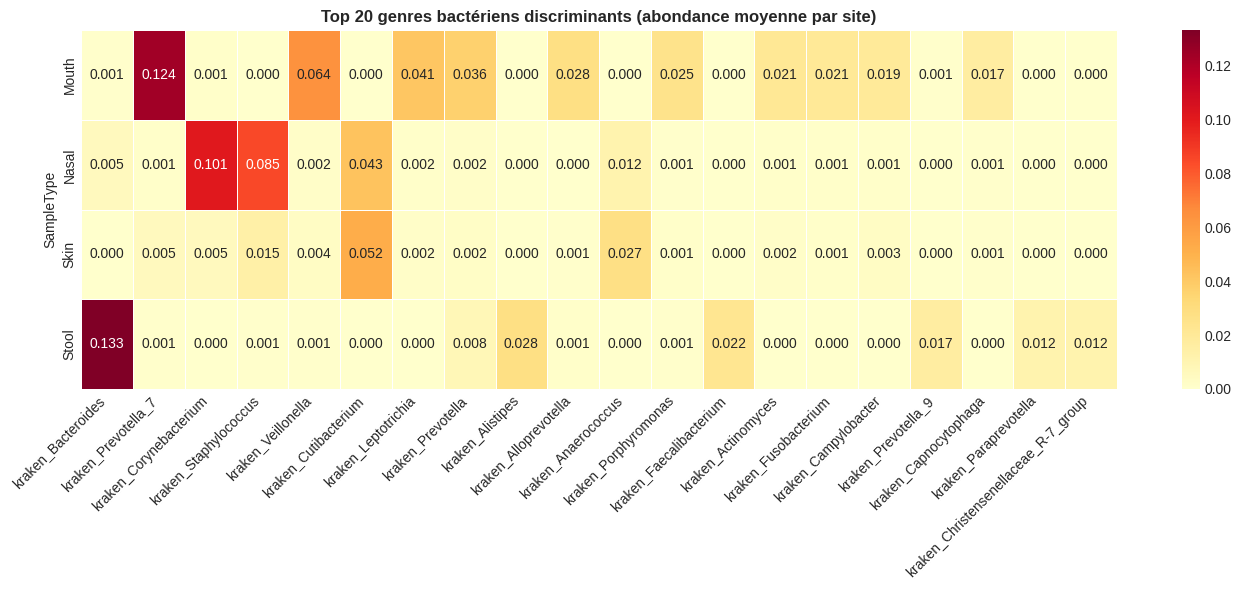

In [22]:
# Kraken2 : top 20 genres discriminants
kraken_cols = [c for c in df_train_final.columns
               if c.startswith('kraken_')
               and c not in ('kraken_unclassified', 'kraken_n_genera')]
if kraken_cols:
    genus_by_site  = df_train_final.groupby('SampleType')[kraken_cols].mean()
    top20_genera   = genus_by_site.var(axis=0).nlargest(20).index.tolist()
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(genus_by_site[top20_genera], annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title('Top 20 genres bactériens discriminants (abondance moyenne par site)', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '03_kraken2_top20_genera.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('ℹ️  Pas de features Kraken2 — visualisation ignorée')


## 7. Sauvegarde

In [23]:
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

train_df.to_csv(PROCESSED_PATH / 'train_engineered.csv',  index=False)
val_df.to_csv(PROCESSED_PATH   / 'val_engineered.csv',    index=False)
df_test_final.to_csv(PROCESSED_PATH / 'test_engineered.csv', index=False)
pd.Series(feature_cols, name='feature').to_csv(
    PROCESSED_PATH / 'feature_cols.csv', index=False
)

print(f'{"="*55}')
print(f'SAUVEGARDE — {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'{"="*55}')
print(f'  train_engineered.csv → {train_df.shape}')
print(f'  val_engineered.csv   → {val_df.shape}')
print(f'  test_engineered.csv  → {df_test_final.shape}')
print(f'  feature_cols.csv     → {len(feature_cols)} features')
print(f'{"="*55}')


SAUVEGARDE — 2026-05-04 06:21:36
  train_engineered.csv → (2463, 208)
  val_engineered.csv   → (438, 208)
  test_engineered.csv  → (1068, 205)
  feature_cols.csv     → 204 features


## Résumé du Notebook 3

| Famille | N | Justification |
|---------|---|---------------|
| Fractions brutes + qualité | 8 | data_processing.py |
| Ratios biologiques | 4 | Lobry 1996 ; Forsdyke 2000 |
| K-mers (k=3) | 64 | Woloszynek 2019 ; MicroPheno 2018 |
| Dinucléotides relatifs | 16 | Karlin & Burge 1995 |
| Qualité Q20/Q30 | 2 | Standard Illumina |
| **Complexité séq.** | 7 | Proxy diversité taxonomique |
| **Taxonomie Kraken2** | ≤500 | Knights 2011 ; Wood 2019 |

**Fichier généré**:

| Fichier | Contenu |
|---------|----------|
| `train_engineered.csv` | Train (80% sujets) |
| `val_engineered.csv` | Validation (20% sujets) |
| `test_engineered.csv` | Test (sans labels) |
| `feature_cols.csv` | Noms des features |
